In [1]:
import pandas as pd
import plotly.express as px
import os

os.makedirs(r"c:\Users\deepk\mf_analytics\charts", exist_ok=True)

In [2]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.


In [3]:
nav_df = pd.read_csv(r"c:\Users\deepk\mf_analytics\data\processed\nav_history_clean.csv")
fund_df = pd.read_csv(r"c:\Users\deepk\mf_analytics\data\processed\fund_master_clean.csv")

merged_df = nav_df.merge(fund_df[["amfi_code", "scheme_name"]], on="amfi_code", how="left")
merged_df["date"] = pd.to_datetime(merged_df["date"])
merged_df = merged_df[(merged_df["date"] >= "2022-01-01") & (merged_df["date"] <= "2026-12-31")]

print(merged_df.shape)
print(merged_df["scheme_name"].nunique(), "schemes")

(46000, 4)
40 schemes


In [5]:
fig = px.line(
    merged_df,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={"date": "Date", "nav": "NAV (₹)", "scheme_name": "Scheme"}
)

fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="lightgreen", opacity=0.2, line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

fig.add_vrect(
    x0="2024-06-01", x1="2024-10-31",
    fillcolor="lightcoral", opacity=0.2, line_width=0,
    annotation_text="2024 Correction", annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=700,
    legend_title="Scheme",
    legend=dict(font=dict(size=9))
)

fig.write_image(r"c:\Users\deepk\mf_analytics\charts\chart_01_nav_trend.png", scale=2)

## EDA Finding 1 — NAV Trend Analysis
Equity schemes showed strong appreciation through 2023 (bull run), 
followed by a visible mid-2024 correction in small/mid-cap funds.  
*Refer: chart_01_nav_trend.png*

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

aum_df["date"] = pd.to_datetime(aum_df["date"])
aum_df["year"] = aum_df["date"].dt.year

# Kept only March snapshot for each year
aum_yearly = aum_df[aum_df["date"].dt.month == 3]
aum_yearly = aum_yearly[aum_yearly["year"].between(2022, 2025)]

print(aum_yearly["year"].unique())
print(aum_yearly["fund_house"].nunique(), "fund houses")
print(aum_yearly.head(5))

[2022 2023 2024 2025]
10 fund houses
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


C:\Users\deepk\AppData\Local\Temp\ipykernel_26892\3080374702.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



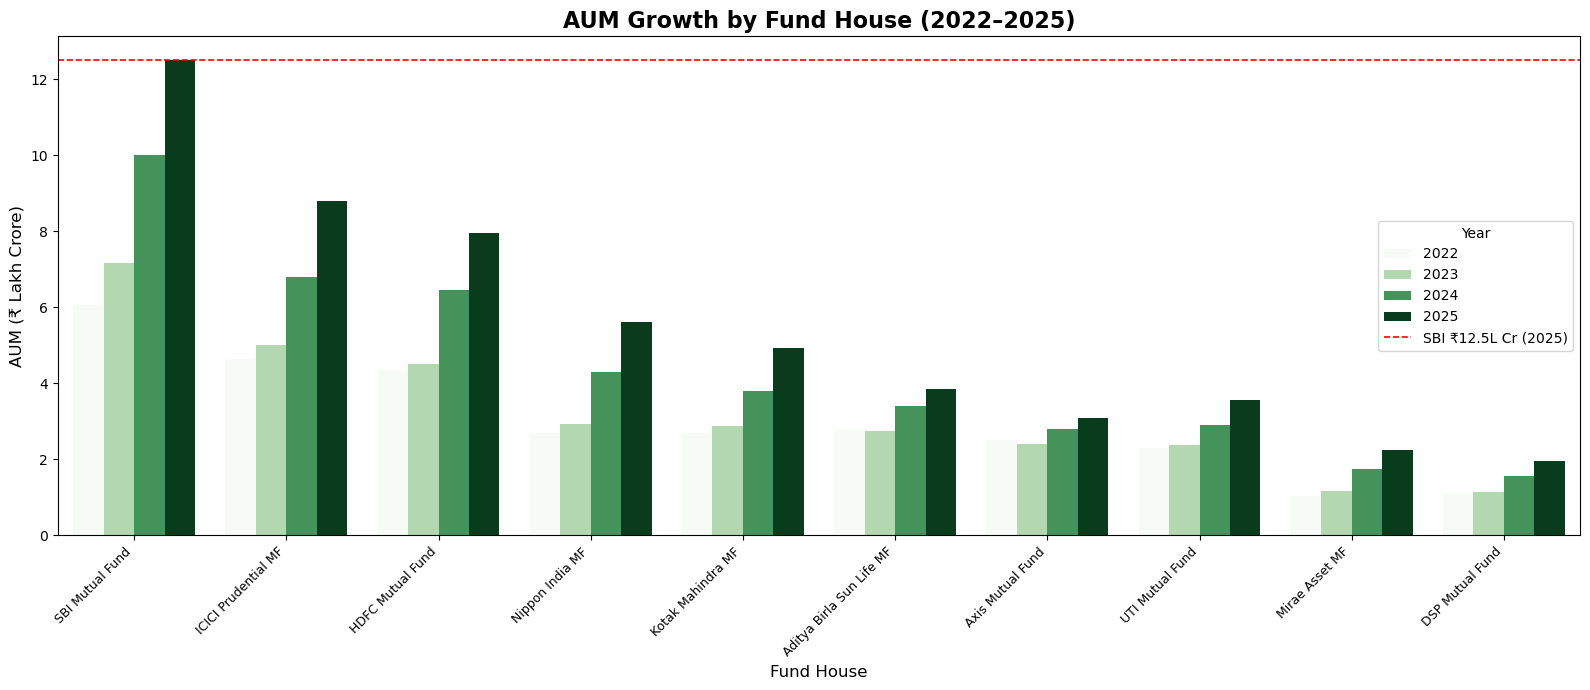

In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    palette="Greens",
    ax=ax
)

# Highlight SBI bar annotation
ax.axhline(y=12.5, color="red", linestyle="--", linewidth=1.2, label="SBI ₹12.5L Cr (2025)")

ax.set_title("AUM Growth by Fund House (2022–2025)", fontsize=16, fontweight="bold")
ax.set_xlabel("Fund House", fontsize=12)
ax.set_ylabel("AUM (₹ Lakh Crore)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.legend(title="Year")

plt.tight_layout()
plt.savefig(r"c:\Users\deepk\mf_analytics\charts\chart_02_aum_growth.png", dpi=150)

## EDA Finding 2 — AUM Growth by Fund House
SBI Mutual Fund leads with ₹12.5L Cr AUM by 2025, nearly doubling 
its 2022 figure, reflecting consistent investor trust in PSU-backed funds.  
*Refer: chart_02_aum_growth.png*

In [11]:
sip_df["month"] = pd.to_datetime(sip_df["month"])
sip_df = sip_df.sort_values("month")

# Confirm the Dec 2025 peak
print(sip_df.loc[sip_df["sip_inflow_crore"].idxmax()])

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [13]:
fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={"month": "Month", "sip_inflow_crore": "SIP Inflow (₹ Crore)"},
    markers=True
)

# Annotate all-time high
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr<br>All-Time High",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="red", size=12),
    bgcolor="white",
    bordercolor="red"
)

fig.update_traces(line=dict(color="royalblue", width=2))
fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=500
)

fig.write_image(r"c:\Users\deepk\mf_analytics\charts\chart_03_sip_inflow.png", scale=2)

## EDA Finding 3 — SIP Inflow Trend
Monthly SIP inflows grew consistently from ₹11,517 Cr (Jan 2022) 
to an all-time high of ₹31,002 Cr (Dec 2025), reflecting rising 
retail participation in mutual funds.  
*Refer: chart_03_sip_inflow.png*

In [15]:
cat_df["month"] = pd.to_datetime(cat_df["month"])
cat_df = cat_df.sort_values("month")

# categories as rows, months as columns
pivot_df = cat_df.pivot_table(index="category", columns="month", values="net_inflow_crore")

# Formating column labels to MMM-YY for readability
pivot_df.columns = pivot_df.columns.strftime("%b-%y")

print(pivot_df.shape)
print(pivot_df.head(3))

(12, 12)
month      Apr-24  May-24  Jun-24  Jul-24  Aug-24  Sep-24  Oct-24  Nov-24  \
category                                                                    
ELSS        466.0   553.0   472.0   471.0   499.0   537.0   537.0   571.0   
Flexi Cap  4947.0  5529.0  4478.0  4869.0  5562.0  5397.0  6004.0  6111.0   
Gilt        784.0   836.0   864.0   959.0   952.0   925.0   898.0   704.0   

month      Dec-24  Jan-25  Feb-25  Mar-25  
category                                   
ELSS        521.0   516.0   437.0   500.0  
Flexi Cap  4654.0  5603.0  6068.0  4767.0  
Gilt        831.0   744.0   942.0   956.0  


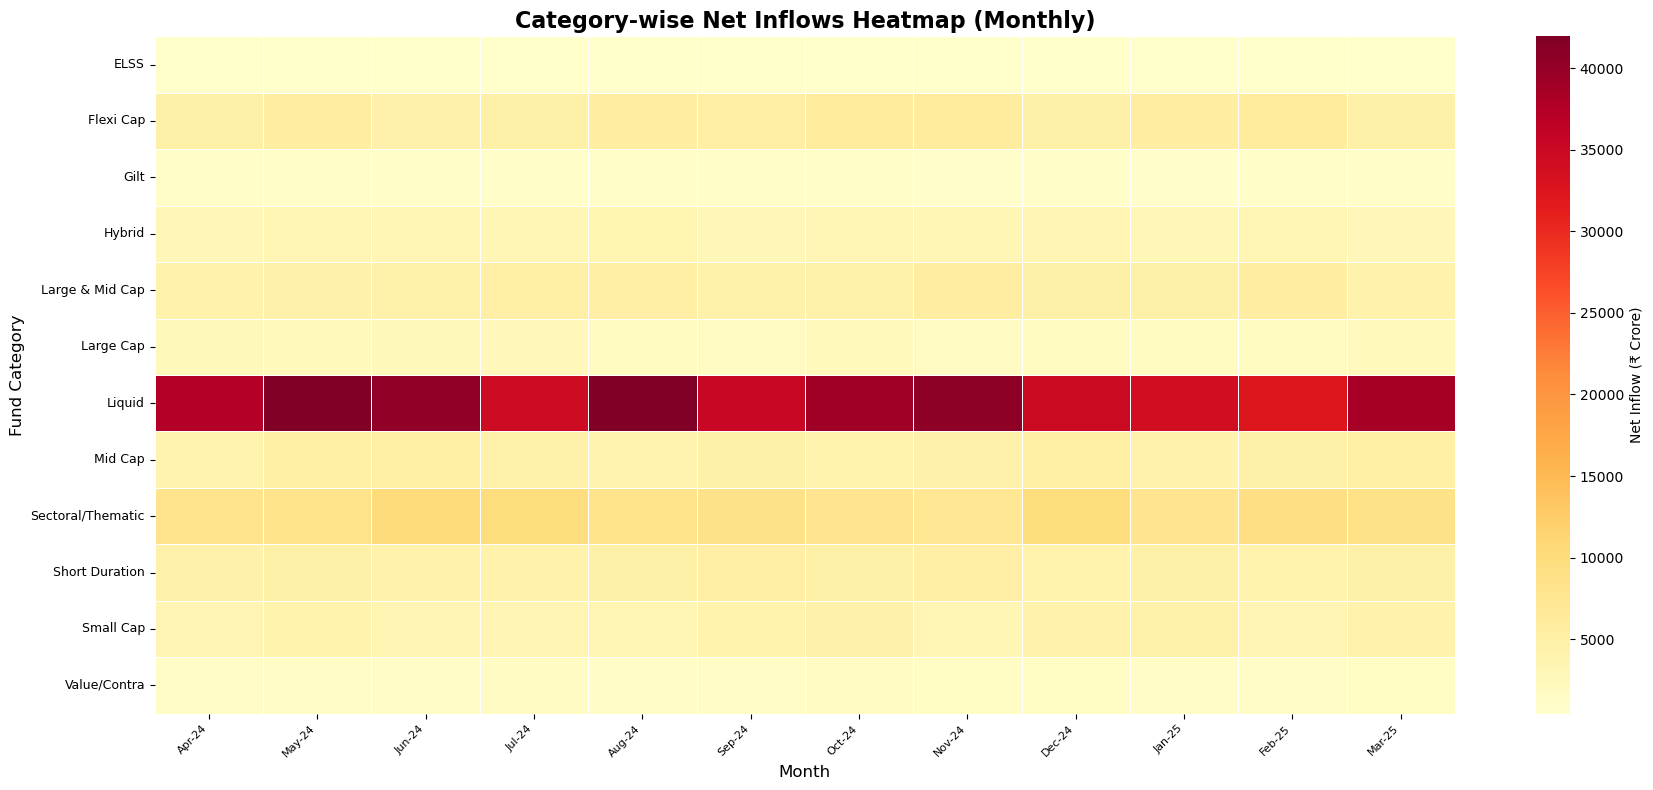

In [16]:
fig, ax = plt.subplots(figsize=(18, 8))

sns.heatmap(
    pivot_df,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Net Inflow (₹ Crore)"},
    ax=ax
)

ax.set_title("Category-wise Net Inflows Heatmap (Monthly)", fontsize=16, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Fund Category", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(r"c:\Users\deepk\mf_analytics\charts\chart_04_category_heatmap.png", dpi=150)

## EDA Finding 4 — Category Inflow Heatmap
Flexi Cap and Small Cap funds consistently attracted the highest 
net inflows across months, while Debt categories showed muted 
and seasonal inflow patterns.  
*Refer: chart_04_category_heatmap.png*

C:\Users\deepk\AppData\Local\Temp\ipykernel_26892\2340097630.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




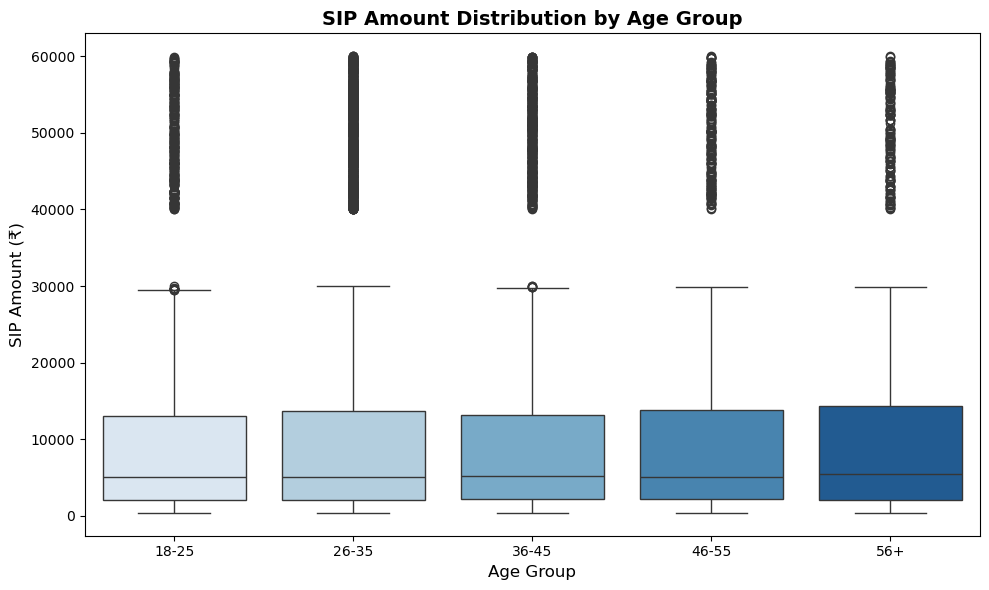

In [21]:
sip_only = txn_df[txn_df["transaction_type"] == "SIP"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=sip_only,
    x="age_group",
    y="amount_inr",
    palette="Blues",
    order=["18-25", "26-35", "36-45", "46-55", "56+"],
    ax=ax
)

ax.set_title("SIP Amount Distribution by Age Group", fontsize=14, fontweight="bold")
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("SIP Amount (₹)", fontsize=12)

plt.tight_layout()
plt.savefig(r"c:\Users\deepk\mf_analytics\charts\chart_05b_sip_by_age.png", dpi=150)

In [20]:
gender_counts = txn_df["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]

fig_gender = px.pie(
    gender_counts,
    names="gender",
    values="count",
    title="Investor Gender Split",
    color_discrete_sequence=["royalblue", "lightcoral"],
    hole=0.3
)
fig_gender.update_traces(textposition="inside", textinfo="percent+label")
fig_gender.update_layout(height=500)

fig_gender.write_image(r"c:\Users\deepk\mf_analytics\charts\chart_05c_gender_split.png", scale=2)

## EDA Finding 5 — Investor Demographics
The 26-35 age group dominates SIP participation, while 56+ investors 
contribute higher per-SIP amounts. Male investors account for a 
slightly larger share but gender parity is improving.  
*Refer: chart_05a_age_distribution.png, chart_05b_sip_by_age.png, chart_05c_gender_split.png*